In [2]:
# do not install FACTM from https://github.com/lazeckam/FACTMpy
# because it is not updated
from FACTMpy import FACTModel

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Generate data

In [4]:
def simulations_sample_fa(K, N, D, M, 
                          sparsity_factor_fraction=0.2, check_sparsity_factor=True, 
                          sparsity_feature_fraction=0.2, check_sparsity_feature=True,
                          var_data=None, var_weights=None,
                          write_all=False, 
                          data_centered=True, muFA_scale=None, seed=123, which_ctm=None):
    
    np.random.seed(seed)
    
    ### Setting variances for data and w if not provided
    #### Default var=1

    if var_data is None:
        var_data = []
        for m in range(M):
            var_data.append(np.ones((N, D[m])))

    if var_weights is None:
        var_weights = []
        for m in range(M):
            var_weights.append(np.ones((D[m], K)))


    ### Setting weights scale to 1, if not provided
    #### This is the parameter to scale down/up the weights to test their influence on the model 
    #### Especially needed to test a link FA - CTM 
            
    if muFA_scale is None:
        muFA_scale = np.ones((M))


    ### Sampling in which view which factors are/are not active

    sparsity_factor_number = np.floor(sparsity_factor_fraction*K*M).astype('int')
    sparsity_factor_not_set = True

    while check_sparsity_factor or sparsity_factor_not_set:
        sparsity_factor_indicator_flat = np.random.choice(np.arange(0, np.array(K*M).astype('int')), size=sparsity_factor_number, replace=False)
        sparsity_factor_indicator_indeces = divmod(sparsity_factor_indicator_flat, M)
        check_sparsity_factor = np.any(np.unique(sparsity_factor_indicator_indeces[0], return_counts=True)[1] == M)
        sparsity_factor_not_set = False

    sparsity_factor_indicator = np.zeros((K, M))
    sparsity_factor_indicator[sparsity_factor_indicator_indeces[0], sparsity_factor_indicator_indeces[1]] = 1

    factorwise_sparsity = sparsity_factor_indicator


    ### Sampling weights (+ adding feature-wise sparsity)

    weights = []
    featurewise_sparsity = []
    for m in range(M):

        weights_not_sparse_m = np.random.normal(size=(D[m], K), scale=np.sqrt(var_weights[m]))

        sparsity_feature_number_m = np.floor(sparsity_feature_fraction*D[m]*K).astype('int')
        sparsity_feature_not_set_m = True

        while check_sparsity_feature or sparsity_feature_not_set_m:
            sparsity_feature_indicator_flat_m = np.random.choice(np.arange(0, np.array(D[m]*K).astype('int')), size=sparsity_feature_number_m, replace=False)
            sparsity_feature_indicator_indeces_m = divmod(sparsity_feature_indicator_flat_m, D[m])
            check_sparsity_feature = np.any(np.unique(sparsity_feature_indicator_indeces_m[0], return_counts=True)[1] == D[m])
            sparsity_feature_not_set_m = False

        sparsity_feature_indicator_m = np.zeros((D[m], K))
        sparsity_feature_indicator_m[sparsity_feature_indicator_indeces_m[1], sparsity_feature_indicator_indeces_m[0]] = 1

        weights_sparse_m = weights_not_sparse_m * (1 - sparsity_feature_indicator_m)

        weights.append(weights_sparse_m)
        featurewise_sparsity.append(sparsity_feature_indicator_m)


    ### Sampling hidden factors
        
    z = np.random.normal(size=(N, K))


    ### Sampling views (observed data)

    fa_data = dict()
    for m in range(M):
        if which_ctm[m]:
            fa_data_m = np.dot(z, weights[m].T)
        else:
            fa_data_m = np.random.normal(np.dot(z, weights[m].T), np.sqrt(var_data[m]))
        # if data_centered:
        #     fa_data_m = (fa_data_m - np.mean(fa_data_m, axis=0))
        fa_data['M'+str(m)] = fa_data_m


    ### Saving information which would not be observed for real data
        
    artificial_data_info = {'z': z,
                            'w': weights,
                            'featurewise_sparsity': featurewise_sparsity,
                            'factorwise_sparsity': factorwise_sparsity}
    
    params = {'K': K,
              'N': N, 
              'D': D,           
              'M': M}
    
    if write_all:
        params['var_weights'] = np.array([var_weights[m][0,:] for m in range(M)])
        params['var_data'] = [var_data[m][0,:] for m in range(M)]
    
    artificial_data_info['params'] = params

    return fa_data, artificial_data_info


def simulations_sample_ctm(N, G, L, 
                           sentences_per_observation=None, sentences_per_observation_params=None, 
                           words_per_sentence=None,
                           topics_params=None,
                           FA=False, 
                           mu0=None, muFA=None, Sigma0=None, seed=123):
    
    np.random.seed(seed)
    
    ### Sampling topics (distributions on words) from 
    #### The default is symmetric 
    ####  and is chosen in a way that the topics are sparse (alpha < 1) but not to sparse (alpha > 1/G)

    if topics_params is None:
        topics_params = np.ones(G)/np.sqrt(G)   

    topics = np.random.dirichlet(topics_params, size=L)


    ### Setting number of sentences in each observation
    #### That number might be constant or chosen randomly (so the number of sentences varie across samples)

    if sentences_per_observation is None:
        sentences = 10*np.ones(N)
    if sentences_per_observation == 'constant':
        sentences = sentences_per_observation_params['const']*np.ones(N)
    if sentences_per_observation == 'negative_binomial':
        sentences = np.random.negative_binomial(n=sentences_per_observation_params['n'], p=sentences_per_observation_params['p'], size=N) + 1
    if sentences_per_observation == 'poisson':
        sentences = np.random.poisson(lam=sentences_per_observation_params['lambda'], size=N) + 1
    sentences = sentences.astype('int')
    words_per_sentence = int(words_per_sentence)


    ### Topics proportion in each observation
    #### Set via mu0, the default is that all probabilities are equal
    #### If FA = True, then the proportion varies across observations

    if mu0 is None:
        mu0 = np.zeros(L)
    if Sigma0 is None:
        Sigma0 = np.eye(L)
    if muFA is None:
        if FA:
            muFA = np.random.normal(size=(N, L))
        else:
            muFA = np.zeros((N, L))
    mu_per_observation = muFA + mu0
    eta_per_observation = np.zeros((N,L))
    for n in range(N):
        eta_per_observation[n,:] = np.random.multivariate_normal(mu_per_observation[n,:], Sigma0)
        
    topics_proportion_observation = np.exp(eta_per_observation)
    topics_proportion_observation = topics_proportion_observation/np.outer(np.sum(topics_proportion_observation, axis=1), np.ones(L))


    ### Generating data
        
    ctm_data = []
    topics_per_sentence = []
    topics_proportion_per_observation = []

    for n in range(N):
        topics_ind_n = np.random.choice(int(L), p=topics_proportion_observation[n,:], size=int(sentences[n]))

        topics_proportion_per_observation.append(topics_proportion_observation[n,:])
        topics_per_sentence.append(topics_ind_n)

        ctm_data_n = np.zeros((int(sentences[n]), G))
        for i in range(int(sentences[n])):
            for j in range(words_per_sentence):
                ctm_data_n[i, np.random.choice(int(G), size=1, p=topics[topics_ind_n[i],:])] += 1
        ctm_data.append(ctm_data_n)


    ### Saving information which would not be observed for real 
    
    artificial_data_info = {'topics': topics,
                            'sentences': sentences,
                            'muFA': muFA,
                            'eta': eta_per_observation,
                            'topics_proportion_per_observation': topics_proportion_per_observation,
                            'topics_per_sentence': topics_per_sentence}

    return ctm_data, artificial_data_info

def simulations_sample_factm(which_ctm, simulations_sample_fa_params, simulations_sample_ctm_params, seed):

    np.random.seed(seed)

    if sum(which_ctm) != 1:
        pass
        #Error('There should be just one view')

    factm_data = {}
    fa_data, fa_artificial_data_info = simulations_sample_fa(**simulations_sample_fa_params, seed=seed)

    for m in range(simulations_sample_fa_params['M']):

        if which_ctm[m]:
            ctm_data, ctm_artificial_data_info = simulations_sample_ctm(muFA = fa_data['M'+str(m)], **simulations_sample_ctm_params, seed=seed)
            factm_data['M'+str(m)] = ctm_data
        else:
            factm_data['M'+str(m)] = fa_data['M'+str(m)]


    return factm_data, fa_artificial_data_info, ctm_artificial_data_info
    

In [13]:
N = 100 # number of observations 
M = 3 # number of views
K = 5 # number of hidden factors
D = [10, 15, 20] # number of features in views

G = 80 # number of distinct words
L = D[2] # number of topics (the last view is not observed directly - we observe words)

# covariance matrix in CTM:
Sigma0 = np.eye(L)
Sigma0 = Sigma0 + 0.5*(np.tri(L, L, -1) - np.tri(L, L, -2)) + 0.5*(np.tri(L, L, -1) - np.tri(L, L, -2)).T
mu0 = np.zeros(L)
# data variances in FA:

var_weights = []
var_weight_M0 = np.ones((D[0], K))
var_weight_M0[:,1] = 0
var_weight_M0[:,4] = 0
var_weight_M1 = np.ones((D[1], K))
var_weight_M1[:,2] = 0
var_weight_M2 = np.ones((D[2], K))
var_weight_M2[:,3:] = 0
var_weights = [var_weight_M0, var_weight_M1, var_weight_M2]
# setting parameters:

# which_ctm = [True, True, True]
which_ctm = [False, False, True]
simulations_sample_fa_params = {'K': K, 'N': N, 'D': D, 'M': M, 'sparsity_factor_fraction': 0, 'sparsity_feature_fraction': 0,
                                'var_weights': var_weights, 'which_ctm': which_ctm}
simulations_sample_ctm_params = {'N': N, 'G': G, 'L': L, 'sentences_per_observation': 'constant', 
                                'sentences_per_observation_params': {'const': 10},
                                'words_per_sentence': 100, 'FA': True, #1000
                                'mu0': mu0,
                                'Sigma0': Sigma0, 'topics_params': np.ones(G)}


simulations_sample_params =  {'simulations_sample_fa_params': simulations_sample_fa_params,
                                'simulations_sample_ctm_params': simulations_sample_ctm_params,
                                'which_ctm': which_ctm}

In [14]:
data_simulations, data_fa_info, data_ctm_info = simulations_sample_factm(**simulations_sample_params, seed=123)

In [ ]:
from dataclasses import dataclass

@dataclass
class SimpleData:
    data: np.ndarray
    factors: int
    likelihood: np.array # change to dist.
    prior: np.ndarray
    
    def __post_init__(self):
        if len(self.priors) != self.data.shape[0]:
            raise ValueError(f"Length of priors ({len(self.priors)}) must match first dimension of data ({self.data.shape[0]})")
        
    
class StructuredData:
    data: np.array
    topics: int

## FACTM

In [ ]:
factm = FACTModel(data=data_simulations, K=5, L=[L], 
                  likelihoods=['normal','normal','CTM'], # data distribution in M0, M1, M2
                  W_priors=['ARD','ARD','None'], # sparsity
                  seed=123)

{'M0': array([[ 4.05712172e+00,  9.82336241e-01, -2.00046538e+00,
         -1.56848177e+00,  1.74955717e+00, -2.05204927e-01,
         -2.26873495e+00,  3.66090529e+00, -1.83920380e+00,
          6.99275113e-01],
        [-2.95978624e+00, -8.90075442e-01,  8.01123945e-01,
          1.47225801e+00, -1.28705493e-01,  5.18650086e-01,
         -2.43898133e+00, -8.70438714e-01,  4.03390668e-01,
         -3.88676964e+00],
        [-1.47788584e+00,  5.18373254e-01,  6.29219154e+00,
          3.73894306e+00, -3.85432054e+00, -5.59180258e+00,
          1.71902212e-02,  4.04224331e-03, -1.45842280e+00,
          6.14561690e+00],
        [-5.91289199e-01,  2.50409902e+00,  3.21479589e+00,
          2.29139448e+00, -4.30250722e-01, -3.97617258e+00,
          4.11431540e-01, -1.45163181e+00,  2.19704487e+00,
          4.90585572e-01],
        [ 5.61203884e-01,  2.08513519e-01, -1.03272015e-01,
         -3.01922841e+00,  1.34676175e+00,  1.44979614e+00,
          1.89682828e+00, -5.25748085e-01, -4.

In [25]:
factm.fit(100, pretrain=True, elbo_tres=0.1) 

Pretraining CTM for a modality 2
Pretraining FA
Fitting a model.


  0%|          | 0/100 [01:23<?, ?it/s]


KeyboardInterrupt: 

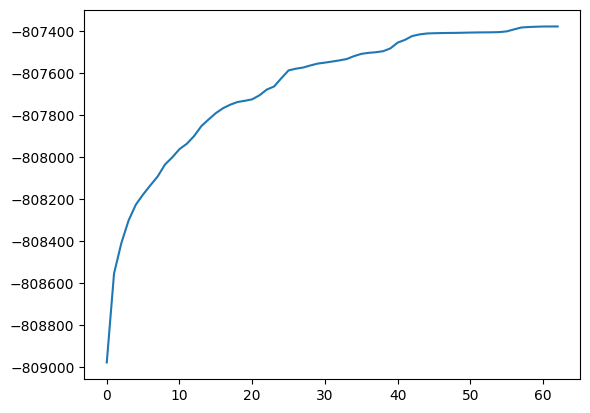

In [11]:
plt.plot(factm.elbo_sequence)

In [12]:
factm.get_latent_factors()

array([[-8.25354601e-01, -4.26043680e-01,  1.61702105e+00,
         8.06244959e-01, -4.24789577e-01],
       [ 9.46234012e-01, -1.34846072e-01, -9.24788331e-01,
        -1.52223863e+00,  1.31991921e-01],
       [ 4.80793354e-01,  2.17661614e+00,  6.59630029e-01,
        -2.02040875e-02, -3.81912025e-01],
       [ 1.30778940e-01,  1.21224264e+00, -4.09952970e-01,
         7.21073533e-01, -7.27533965e-01],
       [-6.01296656e-01, -4.76324767e-01, -1.51879518e+00,
        -4.85683971e-01,  7.14406718e-01],
       [ 5.22719973e-01,  5.83644337e-01, -5.41548974e-02,
         1.95894303e+00, -6.94389023e-01],
       [ 5.85675632e-01, -1.56591951e+00, -3.64009611e-01,
        -5.78948979e-01, -4.11259859e-01],
       [ 2.22038979e+00, -4.62220464e-01,  1.25811119e+00,
         1.08410154e+00,  2.76746598e-01],
       [-7.88404803e-01, -6.87783680e-01,  1.97530231e-01,
        -1.05956003e-01, -3.28044552e-01],
       [-7.82764177e-01, -6.64571771e-02, -1.18984662e+00,
        -5.57192959e-01

In [14]:
factm.fa.node_z.vi_mu, factm.fa.node_z.E_z

(array([[ 0.5810735 , -0.06537023, -0.02884995,  0.2861634 ,  0.00316512],
        [-0.36755306, -1.00711965, -2.02734682,  0.25061106, -0.90211883],
        [-0.05477438,  0.42963027,  0.23577685,  1.66383325,  1.56582916],
        [ 1.00595614, -0.26345855, -0.56818708, -0.22547126, -0.07498124],
        [-0.08121462,  1.33292635, -0.51401863,  0.26079564,  0.32426447],
        [ 1.04097943, -0.20825795, -0.80637209, -0.34645023,  0.68882804],
        [-0.83301669,  0.08530473,  1.86284704, -0.93062949, -0.36804973],
        [ 1.33728984, -0.14820761,  0.33056188,  0.08449422, -0.96732003],
        [ 0.24626067, -0.20203702, -0.29501134, -0.87628366, -0.83535994],
        [ 1.01209521,  0.20559232, -0.2842359 ,  0.32611989, -0.17686507],
        [ 2.44829973, -0.06196505,  0.15898067,  0.70839844,  0.80050413],
        [-0.21136526,  0.28329006,  1.22486171, -0.49704656,  0.9645083 ],
        [ 0.93811999,  0.1627172 ,  0.82799314, -0.03541107, -1.73144329],
        [-0.42839307, -0.